## <font color='46B8A9'> **Caso de Estudio - Aprendizaje Profundo (Redes Neuronales)**


## <font color='8EC044'> **Descripción**

Las instituciones financieras procesan millones de transacciones con tarjetas de crédito a diario. Identificar patrones inusuales que puedan representar fraude es crucial para proteger a los usuarios y minimizar las pérdidas económicas. Este conjunto de datos simula transacciones reales en el oeste de los Estados Unidos, e incluye información relevante sobre el cliente, la transacción, el comercio y si la operación fue o no fraudulenta.

En el presente caso de estudio, se busca desarrollar un modelo de detección de fraude que identifique automáticamente las transacciones sospechosas, basándose en variables como el monto, la ubicación, la hora, y la información del cliente y del comercio. Para ello, se utilizarán redes neuronales, aprovechando su capacidad para detectar relaciones no lineales y patrones ocultos entre múltiples variables. Esto permitirá mejorar la precisión en la detección de fraudes y brindar una herramienta eficaz para apoyar a las entidades financieras en la toma de decisiones preventivas.

## <font color='8EC044'> **Datos**

* **trans_date_trans_time:** Fecha y hora de la transacción

* **merchant:** Nombre del comercio

* **category:** Categoría del comercio

* **amt:** Monto de la transacción

* **city:** Ciudad

* **state:** Estado

* **lat:** Ubicación de la compra (latitud)

* **long** Ubicación de la compra (longitud)

* **city_pop:** Población de la ciudad del titular de la tarjeta de crédito

* **job:** Ocupación del titular de la tarjeta de crédito

* **dob:** Fecha de cumpleaños del titular de la tarjeta de crédito

* **trans_num:** Número de transacción

* **merch_lat:** Ubicación del comercio (latitud)

* **merch_long:** Ubicación del comercio (longitud)

* **is_fraud:** Indica si la transacción es fraudulenta (1) o no (0)

## <font color='8EC044'> **1. Inicialización**

### <font color='FF7F50'> **1.1. Librerías**

In [ ]:
pip install plotly

In [ ]:
!pip install kneed

In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
# Eliminar advertencias
import warnings
warnings.filterwarnings("ignore")

# Datos
import os
from google.colab import files
import pandas as pd
import numpy as np
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Visualización
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import to_rgb, to_rgba
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import random

# Modelado
from keras.layers import Dropout
from keras.regularizers import l2
from tensorflow import keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import Recall
import keras_tuner as kt
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import shutil
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### <font color='FF7F50'> **1.2. Descarga y carga de datos desde Kaggle**

**Instrucciones:**

**1.** Crear un archivo kaggle.json con el token de autenticación (en Kaggle → hacer clic en el ícono de usuario en la esquina superior derecha → configuración → API → crear nuevo token).

**2.** Subir el archivo kaggle.json a este espacio de trabajo de Colab.

In [ ]:
# Subir el archivo kaggle.json
uploaded = files.upload()

Saving kaggle.json to kaggle.json


**3.** Configurar la autenticación con Kaggle usando el archivo kaggle.json y descargar el conjunto de datos desde el repositorio neharoychoudhury/credit-card-fraud-data en el directorio actual.

In [ ]:
# Establecer el directorio de configuración de Kaggle
os.environ['KAGGLE_CONFIG_DIR'] = '.'

# Cambiar permisos del archivo kaggle.json
!chmod 600 ./kaggle.json

# Descargar el dataset de Kaggle
!kaggle datasets download -d neharoychoudhury/credit-card-fraud-data

Dataset URL: https://www.kaggle.com/datasets/neharoychoudhury/credit-card-fraud-data
License(s): MIT
  0% 0.00/839k [00:00<?, ?B/s]
100% 839k/839k [00:00<00:00, 719MB/s]


**4.** Descomprimir e inspeccionar datos.

In [ ]:
!ls

credit-card-fraud-data.zip  kaggle.json  sample_data


In [ ]:
!unzip credit-card-fraud-data.zip > /dev/null

In [ ]:
!wc *.csv

  14447   70144 2613733 fraud_data.csv


**5.** Cargar el dataset con pandas.

In [ ]:
df = pd.read_csv("fraud_data.csv")
df

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,04-01-2019 00:58,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1
1,04-01-2019 15:06,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1
2,04-01-2019 22:37,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1
3,04-01-2019 23:06,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1
4,04-01-2019 23:59,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14441,22-01-2019 00:37,Hudson-Grady,shopping_pos,122.00,Athena,OR,45.8289,-118.4971,1302,Dealer,18-10-1976,699a4c06b22711bf3e0d8ef91232d356,46.442439,-118.524214,0
14442,22-01-2019 00:41,"""Nienow, Ankunding and Collie""",misc_pos,9.07,Gardiner,OR,43.7857,-124.1437,260,"""Engineer, maintenance""",01-09-1956,080d620d24815c7d6c637cf0b71dde8e,42.901265,-124.995317,0
14443,22-01-2019 00:42,Pacocha-O'Reilly,grocery_pos,104.84,Alva,WY,44.6873,-104.4414,110,"""Administrator, local government""",16-05-1973,3c346c8cd627c5fe3ed57430db2e9ae7,45.538062,-104.542117,0
14444,22-01-2019 00:48,"""Bins, Balistreri and Beatty""",shopping_pos,268.16,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",09-11-1939,e66ffcc95ba7fc490486242af1205d04,64.081462,-165.898698,0


### <font color='FF7F50'> **1.3. Funciones**

In [ ]:
def graficar_histograma_y_boxplot(df, columna):
    """
    Genera una visualización combinada que muestra la distribución de una variable numérica
    mediante un histograma y un diagrama de caja (boxplot).

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame que contiene la variable numérica a graficar.

    columna : str
        Nombre de la columna numérica dentro del DataFrame que se desea analizar.

    Detalles del gráfico:
    ---------------------
    - El boxplot se ubica en la parte superior y muestra la mediana, cuartiles y valores atípicos.
    - El histograma se ubica en la parte inferior y representa la frecuencia de los valores en intervalos.
    - Se emplean dos colores distintos (relleno y borde) seleccionados aleatoriamente de la paleta 'viridis'.
    - El eje X es compartido entre ambas visualizaciones para facilitar la comparación.

    Salida:
    -------
    Muestra una figura interactiva de Plotly con el boxplot y el histograma de la variable.
    """

    cmap = cm.get_cmap('viridis', 10)

    # Color 1 para Boxplot
    idx1 = random.randint(0, 9)
    color1 = cmap(idx1)
    color1_rgb = f'rgb({int(color1[0]*255)}, {int(color1[1]*255)}, {int(color1[2]*255)})'
    color1_rgba = f'rgba({int(color1[0]*255)}, {int(color1[1]*255)}, {int(color1[2]*255)}, 0.5)'

    # Color 2 para Histograma
    idx2 = random.choice([i for i in range(10) if i != idx1])
    color2 = cmap(idx2)
    color2_rgb = f'rgb({int(color2[0]*255)}, {int(color2[1]*255)}, {int(color2[2]*255)})'
    color2_rgba = f'rgba({int(color2[0]*255)}, {int(color2[1]*255)}, {int(color2[2]*255)}, 0.5)'

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.4, 0.6],
        vertical_spacing=0.1,
        subplot_titles=(
            f'Boxplot de {columna}',
            f'Histograma de {columna}'
        )
    )

    # Boxplot
    fig.add_trace(
        go.Box(
            y=df[columna],
            name=columna,
            boxpoints='outliers',
            line=dict(color=color1_rgb),
            fillcolor=color1_rgba,
            marker=dict(color=color1_rgb)
        ),
        row=1, col=1
    )

    # Histograma
    fig.add_trace(
        go.Histogram(
            x=df[columna],
            nbinsx=20,
            marker=dict(
                color=color2_rgba,
                line=dict(color=color2_rgb, width=1)
            ),
            name='Frecuencia'
        ),
        row=2, col=1
    )

    # Layout
    fig.update_layout(
        height=700,
        width=1000,
        title={
            'text': f'<b>Distribución de {columna}: Boxplot e histograma</b>',
            'x': 0.5,
            'xanchor': 'center',
        },
        showlegend=False
    )

    fig.update_xaxes(title_text=columna, row=2, col=1)
    fig.update_yaxes(title_text="Frecuencia", row=2, col=1)

    fig.show()

In [ ]:
def graficar_variable_categorica(df, columna):
    """
    Genera un gráfico de barras para visualizar la distribución de una variable categórica, mostrando
    el conteo y porcentaje de cada categoría.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame que contiene la variable a graficar.

    columna : str
        Nombre de la columna categórica dentro del DataFrame cuya distribución se desea visualizar.

    Detalles del gráfico:
    ---------------------
    - El gráfico muestra la frecuencia absoluta por categoría.
    - Cada barra incluye una etiqueta con el conteo y el porcentaje.
    - Se aplican colores personalizados por categoría usando la paleta 'viridis'.
    - Se eliminan NaNs del conteo solo si `dropna=False` se cambia.
    - Las barras tienen bordes más oscuros para mejorar la visualización.
    - No se muestra leyenda, ya que las etiquetas en las barras son autoexplicativas.

    Salida:
    -------
    Muestra una figura interactiva de Plotly con la distribución categórica.
    """

    # Calcular frecuencias
    counts = df[columna].value_counts(dropna=False).reset_index()
    counts.columns = [columna, 'count']

    # Calcular porcentajes y etiquetas
    counts['percentage'] = (counts['count'] / counts['count'].sum()) * 100
    counts['label'] = counts['count'].astype(str) + ' (' + counts['percentage'].round(1).astype(str) + '%)'

    counts[columna] = counts[columna].astype(str)

    categorias = counts[columna].unique()
    cmap = cm.get_cmap('viridis', len(categorias))

    color_discrete_map = {}
    border_colors = {}

    for i, cat in enumerate(categorias):
        rgba = cmap(i)
        fill_rgba = f'rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.6)'
        solid_rgb = f'rgb({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)})'
        color_discrete_map[cat] = fill_rgba
        border_colors[cat] = solid_rgb

    # Crear gráfico
    fig = px.bar(
        counts,
        x=columna,
        y='count',
        color=columna,
        color_discrete_map=color_discrete_map,
        title=f'<b>Distribución de {columna}</b>',
        labels={columna: columna, 'count': 'Frecuencia'},
        text='label',
        width=1000,
        height=600
    )

    for bar in fig.data:
        cat = str(bar.name)
        bar.marker.line.color = border_colors.get(cat, 'black')
        bar.marker.line.width = 1.5

    # Estética final
    fig.update_traces(textposition='outside')
    fig.update_layout(title_x=0.5, showlegend=False)
    fig.show()


In [ ]:
def graficar_mapa(df, columna_lat='lat', columna_long='long', columna_hover=None, titulo='Ubicación de los puntos en el mapa', zoom=5):
    """
    Genera un mapa interactivo con puntos ubicados según latitud y longitud.

    Parámetros:
    - df: DataFrame que contiene las coordenadas.
    - columna_lat: nombre de la columna que contiene la latitud.
    - columna_long: nombre de la columna que contiene la longitud.
    - columna_hover: (opcional) columna para mostrar al pasar el mouse.
    - titulo: título del gráfico.
    - zoom: nivel de zoom del mapa (por defecto 5).

    Retorna:
    - Mapa interactivo con Plotly.
    """
    fig = px.scatter_mapbox(df,
                            lat=columna_lat,
                            lon=columna_long,
                            hover_name=columna_hover,
                            zoom=zoom,
                            height=600,
                            title=titulo)

    fig.update_layout(mapbox_style="open-street-map")
    fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
    fig.show()

In [ ]:
def graficar_distribucion_temporal(df, variable, mostrar_fraude=True, tipo='bar'):
    """
    Grafica la distribución de una variable temporal o categórica.

    Parámetros:
    - df: DataFrame que contiene los datos.
    - variable: columna del DataFrame que se quiere graficar (ej. 'hour', 'month').
    - mostrar_fraude: si es True, desglosa los valores según la variable 'is_fraud'.
    - tipo: tipo de gráfico ('bar' o 'line').

    Requiere que 'is_fraud' esté presente en el DataFrame si mostrar_fraude=True.
    """
    if variable not in df.columns:
        print(f"La variable '{variable}' no está en el DataFrame.")
        return

    if mostrar_fraude and 'is_fraud' not in df.columns:
        print("La columna 'is_fraud' no está en el DataFrame. No se puede mostrar por tipo de transacción.")
        return

    plt.figure(figsize=(12, 6))

    # Generar colores aleatorios desde el colormap viridis
    viridis = cm.get_cmap('viridis', 256)
    color_indices = random.sample(range(256), 2)
    colores = {
        0: {
            'rgb': to_rgb(viridis(color_indices[0])),
            'rgba': to_rgba(viridis(color_indices[0]), alpha=0.4)
        },
        1: {
            'rgb': to_rgb(viridis(color_indices[1])),
            'rgba': to_rgba(viridis(color_indices[1]), alpha=0.4)
        }
    }

    if mostrar_fraude:
        datos = df.groupby([variable, 'is_fraud']).size().reset_index(name='count')

        if tipo == 'bar':
            for fraud_value in sorted(datos['is_fraud'].unique()):
                subset = datos[datos['is_fraud'] == fraud_value]
                plt.bar(
                    subset[variable],
                    subset['count'],
                    label=f'Fraude: {fraud_value}',
                    edgecolor=colores[fraud_value]['rgb'],
                    color=colores[fraud_value]['rgba'],
                    linewidth=1.5
                )
        elif tipo == 'line':
            for fraud_value in sorted(datos['is_fraud'].unique()):
                subset = datos[datos['is_fraud'] == fraud_value]
                plt.plot(
                    subset[variable],
                    subset['count'],
                    label=f'Fraude: {fraud_value}',
                    color=colores[fraud_value]['rgb'],
                    marker='o'
                )
        plt.legend(title='¿Es fraude?')
    else:
        datos = df[variable].value_counts().sort_index()
        color_index = random.randint(0, 255)
        color_rgb = to_rgb(viridis(color_index))
        color_rgba = to_rgba(viridis(color_index), 0.4)
        if tipo == 'bar':
            plt.bar(
                datos.index,
                datos.values,
                edgecolor=color_rgb,
                color=color_rgba,
                linewidth=1.5
            )
        elif tipo == 'line':
            plt.plot(
                datos.index,
                datos.values,
                color=color_rgb,
                marker='o'
            )

    plt.title(f'Distribución de {variable}', fontweight='bold')
    plt.xlabel(variable.capitalize())
    plt.ylabel('Cantidad de transacciones')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [ ]:
'''Función para graficar las curvas de aprendizaje (pérdida y métricas) del modelo a lo largo de las épocas,
   utilizando el historial de entrenamiento devuelto por Keras. Permite visualizar el comportamiento
   del modelo en entrenamiento y validación.'''

def plot_learning_curves(history, title):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.title(title)
    plt.xlabel("Epochs")
    plt.show()

## <font color='8EC044'> **2. Análisis exploratorio de los datos**
En esta etapa se lleva a cabo un análisis exploratorio del conjunto de datos con el objetivo de comprender su estructura, calidad y distribución. Se examinan las dimensiones del DataFrame, los tipos de datos de cada variable y la existencia de valores nulos o inconsistencias. Se presta especial atención a la variable objetivo is_fraud, evaluando su distribución para identificar posibles desbalances entre las clases (transacciones fraudulentas y no fraudulentas).

Asimismo, se analizan las variables categóricas para observar la frecuencia de cada categoría y su posible relación con la ocurrencia de fraude. Por su parte, las variables numéricas se exploran mediante histogramas y diagramas de caja (boxplots), lo que permite detectar valores atípicos y observar tendencias o correlaciones preliminares que podrían ser relevantes para el modelado posterior.

### <font color='FF7F50'> **2.1. Descripción general de los datos**

In [ ]:
# Obtener el número de filas y columnas del DataFrame
rows, cols = df.shape
print(f'Hay {rows} filas y {cols} columnas en el dataset')

Hay 14446 filas y 15 columnas en el dataset


In [ ]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  14446 non-null  object 
 1   merchant               14446 non-null  object 
 2   category               14446 non-null  object 
 3   amt                    14446 non-null  float64
 4   city                   14446 non-null  object 
 5   state                  14446 non-null  object 
 6   lat                    14446 non-null  float64
 7   long                   14446 non-null  float64
 8   city_pop               14446 non-null  int64  
 9   job                    14446 non-null  object 
 10  dob                    14446 non-null  object 
 11  trans_num              14446 non-null  object 
 12  merch_lat              14446 non-null  float64
 13  merch_long             14446 non-null  float64
 14  is_fraud               14446 non-null  object 
dtypes:

In [ ]:
# Contar cuántos valores distintos hay en la columna 'is_fraud'
df['is_fraud'].nunique()

4

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,12600
1,1844
"1""2020-12-24 16:56:24""",1
"0""2019-01-01 00:00:44""",1


En la observación anterior se evidencia un error de formato en la columna is_fraud, donde algunos valores aparecen como cadenas de texto que combinan el indicador de fraude con una fecha. Esto sugiere una escritura incorrecta de los datos, por lo que se procede a limpiar dicha columna para conservar únicamente los valores válidos (0 o 1) y corregir el error.

In [ ]:
# Se reemplaza todo lo que esté después del primer carácter (0 o 1)
df['is_fraud'] = df['is_fraud'].astype(str).str.extract(r'([01])')

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,12601
1,1845


Con el objetivo de enriquecer el análisis temporal de las transacciones, se convirtió las columnas trans_date_trans_time y 'dob' al formato de fecha y hora (datetime). Esta transformación permite extraer características adicionales relevantes como la hora del día, el día de la semana, el mes, el año, y si la transacción ocurrió durante un fin de semana o en horas de la noche. Estas variables derivadas son fundamentales para el modelo de detección de fraude, ya que permiten identificar patrones de comportamiento inusuales, como compras realizadas en horarios atípicos o durante fines de semana, que podrían estar asociadas a actividades fraudulentas.

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%d-%m-%Y %H:%M')
df['dob'] = pd.to_datetime(df['dob'], format='%d-%m-%Y', errors='coerce')

In [ ]:
df['hour'] = df['trans_date_trans_time'].dt.hour            # Hora del día
df['day'] = df['trans_date_trans_time'].dt.day              # Día del mes
df['weekday'] = df['trans_date_trans_time'].dt.weekday      # Día de la semana (0=Lunes)
df['month'] = df['trans_date_trans_time'].dt.month          # Mes
df['year'] = df['trans_date_trans_time'].dt.year            # Año
df['is_weekend'] = df['weekday'].isin([5, 6])               # Sábado o domingo
df['is_night'] = df['hour'].between(0, 6)                   # Transacción nocturna

Se decidió transformar la variable dob para conservar únicamente el año de nacimiento (dob_year), ya que, al tratarse de una fecha, el análisis a nivel de día y mes no aporta información relevante para el contexto del problema. En cambio, el año permite identificar patrones asociados a rangos generacionales o edades, lo cual resulta más útil y manejable para el análisis exploratorio y modelado.

In [ ]:
df['dob_year'] = df['dob'].dt.year

In [ ]:
df.drop(columns=['dob'], inplace=True)

In [ ]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14446 entries, 0 to 14445
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trans_date_trans_time  14446 non-null  datetime64[ns]
 1   merchant               14446 non-null  object        
 2   category               14446 non-null  object        
 3   amt                    14446 non-null  float64       
 4   city                   14446 non-null  object        
 5   state                  14446 non-null  object        
 6   lat                    14446 non-null  float64       
 7   long                   14446 non-null  float64       
 8   city_pop               14446 non-null  int64         
 9   job                    14446 non-null  object        
 10  trans_num              14446 non-null  object        
 11  merch_lat              14446 non-null  float64       
 12  merch_long             14446 non-null  float64       
 13  i

#### **2.1.1. Descripción de variables numéricas**

Mediana, moda, desviación estándar y quantiles:

In [ ]:
# Seleccionar columnas numéricas
cols_excl = ['trans_date_trans_time', 'lat', 'long', 'merch_lat', 'merch_long',
                'hour', 'day', 'weekday', 'month', 'year']

# Filtrar columnas y aplicar describe
df_filt = df.drop(columns=cols_excl, errors='ignore')
df_filt.describe().T

,count,mean,std,min,25%,50%,75%,max
amt,14446.0,124.430073,231.352587,1.0,12.08,51.52,101.03,3261.47
city_pop,14446.0,106537.002838,290291.609056,46.0,493.00,1645.00,35439.00,2383912.00
dob_year,14446.0,1971.343348,17.199682,1927.0,1961.00,1974.00,1985.00,2001.00


#### **2.1.2. Descripción de la variable respuesta**

In [ ]:
graficar_variable_categorica(df, 'is_fraud')

El gráfico de la variable respuesta is_fraud muestra una distribución desbalanceada, donde el 87.2% de las transacciones no son fraudulentas y solo el 12.8% corresponden a fraudes. Esta diferencia en la proporción de clases puede influir negativamente en el desempeño de los modelos predictivos, que tienden a favorecer la clase mayoritaria. Por ello, será importante aplicar técnicas de balanceo.

### <font color='FF7F50'> **2.2. Datos faltantes**

In [ ]:
# Contar la cantidad de valores nulos en cada columna del DataFrame
df.isna().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [ ]:
# Imprimir el número de datos nulos en el dataset
print(f'Los datos nulos en el DataFrame son {df.isnull().sum().sum()}')

Los datos nulos en el DataFrame son 0


### <font color='FF7F50'> **2.3. Datos duplicados**

In [ ]:
# Imprimir el número de datos duplicados en el dataset
print('Los datos duplicados en el DataFrame son', df.duplicated().sum())

Los datos duplicados en el DataFrame son 63


In [ ]:
# Eliminar directamente las filas duplicadas, conservando solo la primera aparición
df.drop_duplicates(inplace=True)
print('Duplicados restantes:', df.duplicated().sum())

Duplicados restantes: 0


In [ ]:
df

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,...,merch_long,is_fraud,hour,day,weekday,month,year,is_weekend,is_night,dob_year
0,2019-01-04 00:58:00,"""Stokes, Christiansen and Sipes""",grocery_net,14.37,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-164.722603,1,0,4,4,1,2019,False,True,1939
1,2019-01-04 15:06:00,Predovic Inc,shopping_net,966.11,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-165.473127,1,15,4,4,1,2019,False,False,1939
2,2019-01-04 22:37:00,Wisozk and Sons,misc_pos,49.61,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-165.914542,1,22,4,4,1,2019,False,False,1939
3,2019-01-04 23:06:00,Murray-Smitham,grocery_pos,295.26,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-166.080207,1,23,4,4,1,2019,False,False,1939
4,2019-01-04 23:59:00,Friesen Lt,health_fitness,18.17,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-165.446843,1,23,4,4,1,2019,False,False,1939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14441,2019-01-22 00:37:00,Hudson-Grady,shopping_pos,122.00,Athena,OR,45.8289,-118.4971,1302,Dealer,...,-118.524214,0,0,22,1,1,2019,False,True,1976
14442,2019-01-22 00:41:00,"""Nienow, Ankunding and Collie""",misc_pos,9.07,Gardiner,OR,43.7857,-124.1437,260,"""Engineer, maintenance""",...,-124.995317,0,0,22,1,1,2019,False,True,1956
14443,2019-01-22 00:42:00,Pacocha-O'Reilly,grocery_pos,104.84,Alva,WY,44.6873,-104.4414,110,"""Administrator, local government""",...,-104.542117,0,0,22,1,1,2019,False,True,1973
14444,2019-01-22 00:48:00,"""Bins, Balistreri and Beatty""",shopping_pos,268.16,Wales,AK,64.7556,-165.6723,145,"""Administrator, education""",...,-165.898698,0,0,22,1,1,2019,False,True,1939


In [ ]:
list(df.columns)

['trans_date_trans_time',
 'merchant',
 'category',
 'amt',
 'city',
 'state',
 'lat',
 'long',
 'city_pop',
 'job',
 'trans_num',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'hour',
 'day',
 'weekday',
 'month',
 'year',
 'is_weekend',
 'is_night',
 'dob_year']

### <font color='FF7F50'> **2.4. Análisis univariado**

In [ ]:
graficar_histograma_y_boxplot(df, 'amt')

Las gráficas correspondientes a la variable amt, que representa el monto de la transacción, evidencian una distribución altamente asimétrica hacia la derecha, con una gran concentración de valores en montos bajos y una presencia significativa de valores atípicos hacia montos altos. El histograma muestra que la mayoría de las transacciones se concentran por debajo de los 500 dólares, mientras que el boxplot revela múltiples outliers que superan con creces el rango intercuartílico, alcanzando montos superiores a los 3.000 dólares. Esta distribución sugiere que, aunque la mayoría de las transacciones son de bajo valor, existe un grupo minoritario de operaciones con montos considerablemente altos que podrían estar asociadas a comportamientos inusuales o fraudulentos, lo cual resulta relevante para el análisis y detección de fraudes.

In [ ]:
graficar_histograma_y_boxplot(df, 'city_pop')

Las gráficas de la variable city_pop, que representa la población de la ciudad del titular de la tarjeta de crédito, muestran una distribución fuertemente sesgada hacia la derecha, con una gran concentración de registros en ciudades pequeñas. El histograma indica que la mayoría de los titulares residen en ciudades con poblaciones inferiores a los 200.000 habitantes, mientras que el boxplot revela una amplia dispersión con valores atípicos significativos que superan ampliamente los 500.000 habitantes, alcanzando un máximo de más de 2 millones. El primer cuartil (Q1) es de 493 y la mediana apenas alcanza los 1.645, lo que confirma que más del 50% de las transacciones provienen de zonas poco pobladas. Esta alta concentración en áreas pequeñas y la presencia de ciudades muy grandes como outliers pueden ser factores importantes al momento de evaluar patrones de comportamiento asociados al fraude, ya que el contexto geográfico y demográfico podría influir en la naturaleza de las transacciones.

In [ ]:
graficar_variable_categorica(df, 'merchant')

El gráfico de la variable merchant, que representa el nombre del comercio donde se realizó cada transacción, muestra una distribución desigual en la frecuencia de apariciones, con algunos comercios registrando una cantidad significativamente mayor de transacciones que otros. Por ejemplo, "Kilback LLC" y "Cormier LLC" destacan como los más frecuentes, con más de 50 transacciones cada uno, mientras que la mayoría de los comercios aparecen con frecuencias considerablemente menores. Esta concentración sugiere que ciertos establecimientos tienen una actividad mucho más alta, lo cual podría estar asociado a su tamaño, tipo de producto o popularidad.

In [ ]:
graficar_variable_categorica(df, 'category')

El gráfico de la variable category, correspondiente a la categoría del comercio donde se realizó la transacción, revela una distribución heterogénea en la frecuencia de los distintos tipos de establecimientos. Se observa que algunas categorías como shopping_pos, gas_transport y grocery_pos concentran la mayoría de las transacciones, lo cual puede estar relacionado con su uso cotidiano y alta frecuencia en la vida diaria de los usuarios. En contraste, otras categorías como home, misc_net o travel presentan una menor cantidad de operaciones. Esta variabilidad en la distribución por categoría es relevante para el análisis de fraude, ya que ciertas categorías, por su naturaleza o forma de pago, podrían ser más propensas a transacciones fraudulentas.

In [ ]:
graficar_variable_categorica(df, 'city')

El gráfico de la variable city, que representa la ciudad del titular de la tarjeta, muestra una distribución marcadamente desigual. Algunas ciudades como Phoenix, Centerview y Orient registran una frecuencia de transacciones significativamente más alta, superando las 300 en el caso de Phoenix, mientras que la mayoría de las ciudades tienen conteos considerablemente menores. Esta fuerte concentración sugiere que un número reducido de ciudades concentra la mayoría de las operaciones, lo cual puede deberse a su tamaño poblacional o nivel de actividad económica. Estas diferencias geográficas podrían ser relevantes en el análisis de fraude, ya que ciertas ubicaciones pueden estar asociadas con patrones de comportamiento particulares o mayor riesgo de transacciones fraudulentas.

In [ ]:
graficar_variable_categorica(df, 'dob_year')

La variable dob_year, que representa el año de nacimiento del titular de la tarjeta, presenta una distribución que se intensifica progresivamente desde 1930 hasta alcanzar un pico entre las décadas de 1970 y 1990, siendo particularmente alta entre 1985 y 1990. Esto indica que la mayoría de los usuarios tienen entre 30 y 40 años, lo cual coincide con una población activa económicamente. También se observa una disminución en frecuencias en los extremos (personas mayores de 70 años o menores de 25), lo cual puede reflejar tanto la distribución etaria real de los clientes como las restricciones de edad para el uso de tarjetas de crédito. Esta variable, relacionada con la edad, puede ser importante para identificar perfiles de comportamiento típicos o inusuales en la detección de fraude.

In [ ]:
graficar_variable_categorica(df, 'state')

El gráfico de la variable state, que representa el estado de residencia del titular de la tarjeta, revela una distribución altamente concentrada. Estados como California (CA) y Missouri (MO) dominan el volumen de transacciones, con un 23.4% y 16.2% del total respectivamente. En contraste, estados como Hawái (HI) y Alaska (AK) muestran una participación marginal, por debajo del 1.2%. Esta concentración geográfica puede estar influenciada por el tamaño poblacional o la actividad comercial en cada estado, y resulta relevante para el análisis de fraude, ya que ciertos estados podrían presentar patrones de comportamiento más propensos a transacciones fraudulentas.

In [ ]:
graficar_variable_categorica(df, 'job')

El gráfico de la variable job, que representa la ocupación del titular de la tarjeta de crédito, muestra una distribución muy dispersa con un gran número de categorías. Algunas profesiones como Surveyor, minerals, Systems analyst destacan con una mayor frecuencia, superando las 200 transacciones, mientras que la mayoría de las ocupaciones tienen frecuencias mucho más bajas. Esta alta diversidad en los tipos de empleo refleja una base de clientes heterogénea, y ciertas ocupaciones podrían estar asociadas a patrones específicos de gasto o riesgo de fraude, lo que puede resultar útil en la segmentación del modelo predictivo.

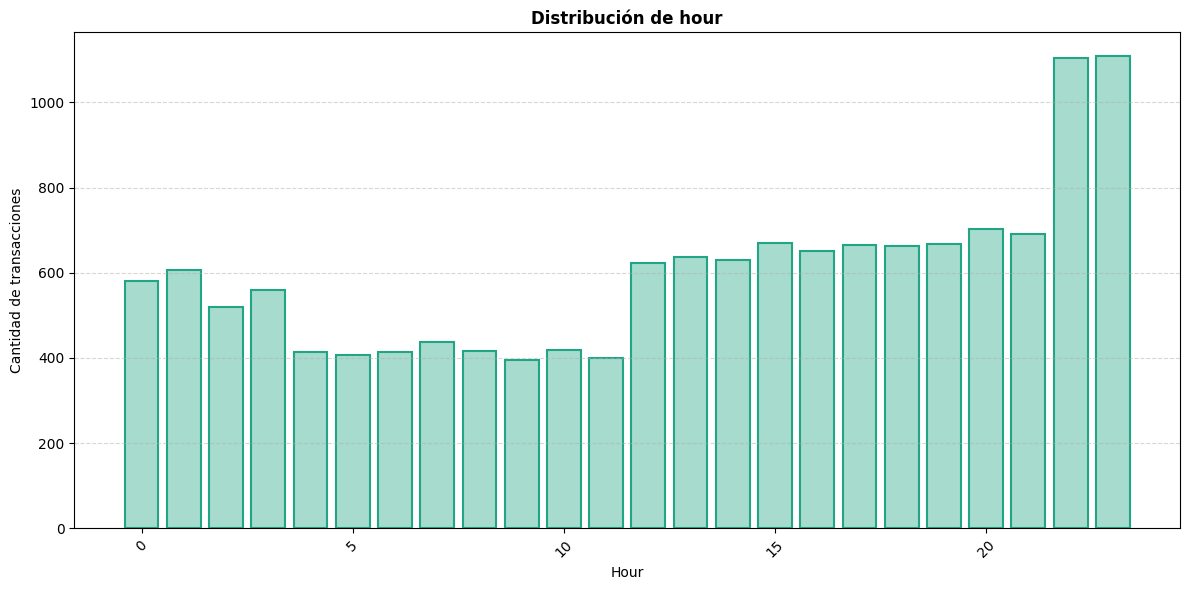

In [ ]:
graficar_distribucion_temporal(df, 'hour', mostrar_fraude=False)

El gráfico de la variable hour, que representa la hora del día en la que se realizó cada transacción, muestra una distribución heterogénea con picos significativos. Se observa una actividad elevada en las horas nocturnas, especialmente entre las 22:00 y 23:00, donde el volumen de transacciones supera las 1.000. En contraste, las horas de la madrugada y la mañana (entre las 4:00 y las 11:00) presentan niveles más bajos de actividad. Este comportamiento podría reflejar patrones de consumo específicos, pero también alertar sobre posibles anomalías, ya que los fraudes suelen concentrarse en horarios menos comunes. Por tanto, la variable hour es clave para detectar transacciones atípicas en función del momento del día.

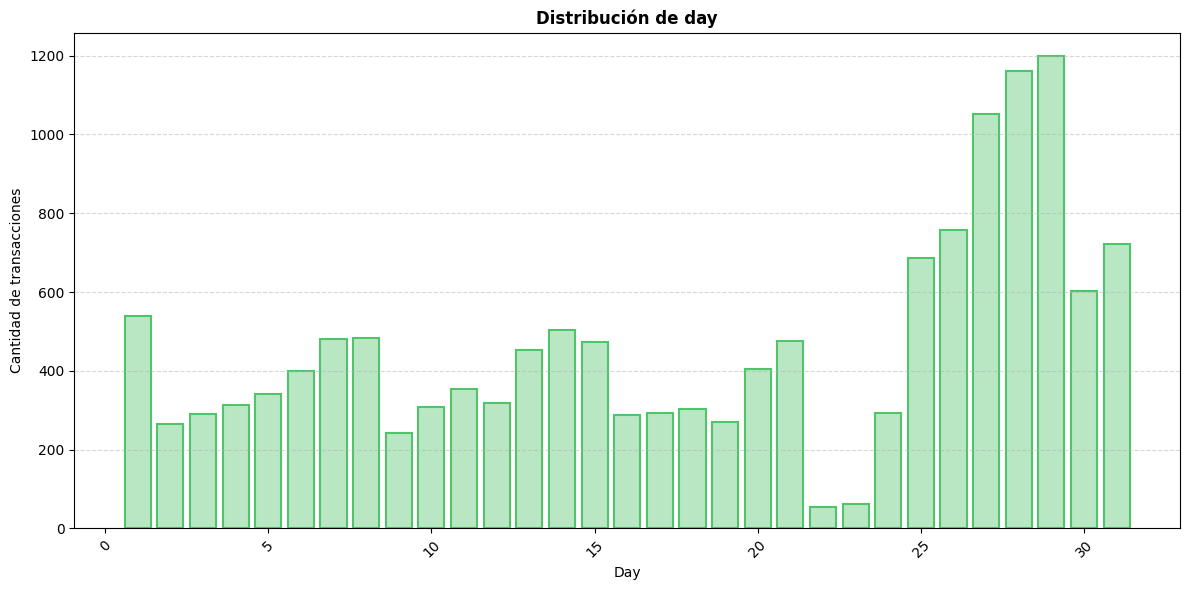

In [ ]:
graficar_distribucion_temporal(df, 'day', mostrar_fraude=False)

La gráfica de la variable day, que representa el día del mes en que se realizó la transacción, revela una distribución desigual. Se destacan picos marcados hacia el final del mes, particularmente entre los días 27 y 30, donde se registra la mayor cantidad de transacciones, superando las 1.200 en el día 30. En contraste, los días 21 y 22 muestran una actividad mínima. Esta concentración al final del mes puede estar relacionada con fechas de pago o cierre de ciclos de facturación, pero también podría indicar comportamientos atípicos o estrategias fraudulentas que aprovechan estos momentos de mayor flujo financiero. Este patrón temporal es relevante para la detección de anomalías.

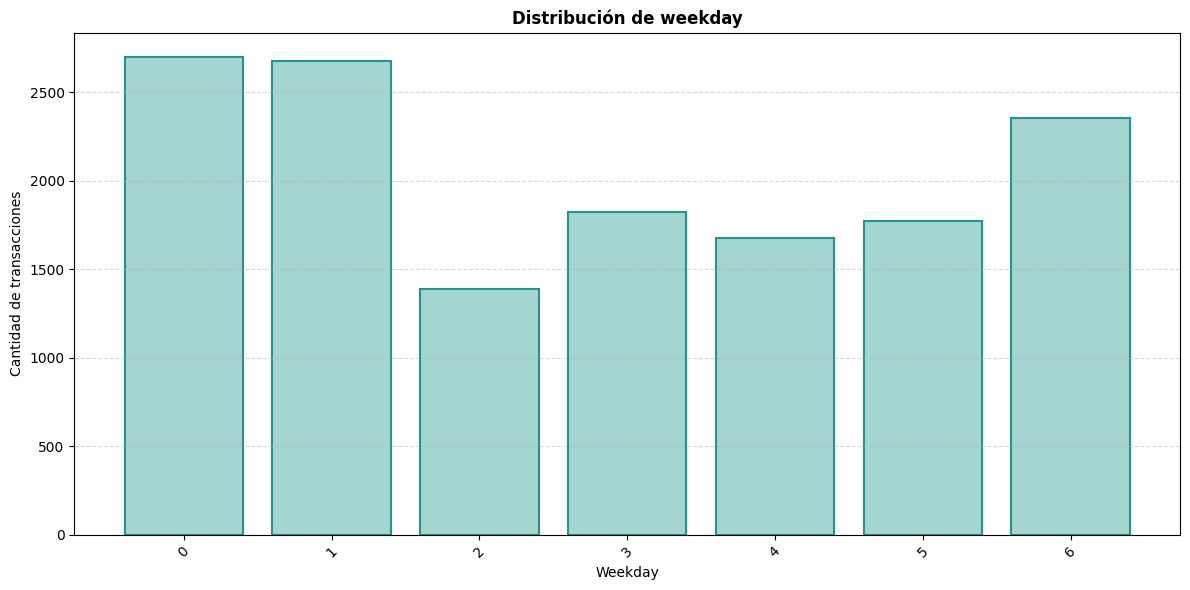

In [ ]:
graficar_distribucion_temporal(df, 'weekday', mostrar_fraude=False)

La gráfica de la variable weekday, que indica el día de la semana en que se realizó cada transacción (donde 0 es lunes y 6 es domingo), muestra que los lunes y martes concentran la mayor cantidad de transacciones, con más de 2.600 cada uno. En cambio, el miércoles (valor 2) presenta la menor actividad, seguido de una recuperación progresiva hacia el fin de semana, con un nuevo pico los domingos. Esta distribución sugiere un patrón de comportamiento en el que las transacciones se incrementan a inicios y fines de semana, posiblemente influenciado por rutinas laborales o hábitos de consumo. Estas variaciones temporales pueden ser útiles para identificar comportamientos fuera de lo común que podrían asociarse a fraudes.

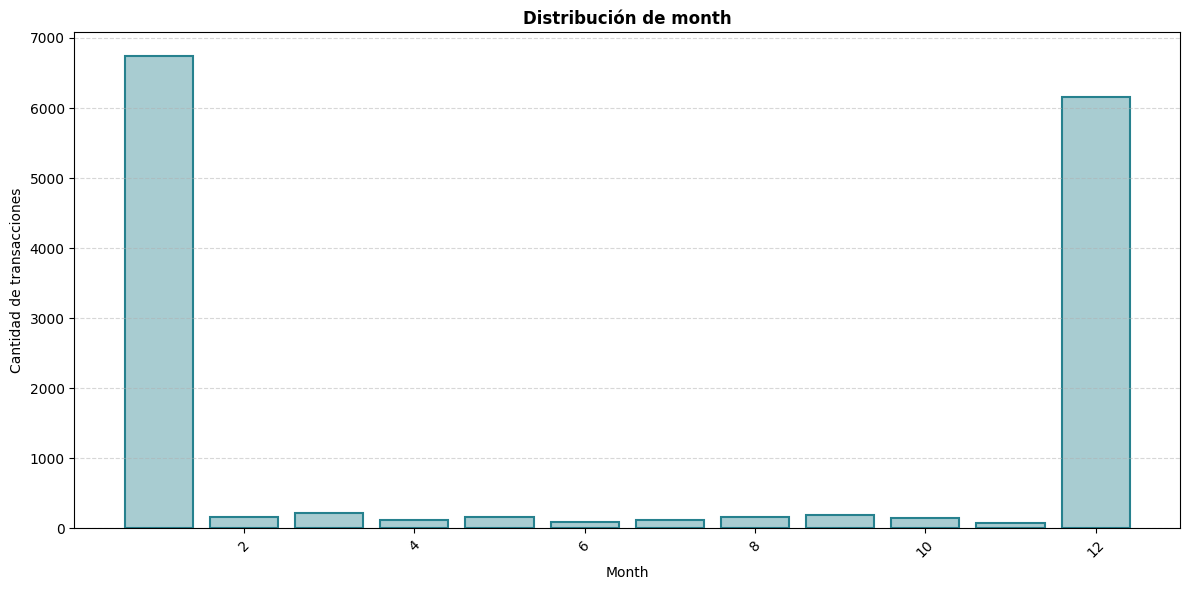

In [ ]:
graficar_distribucion_temporal(df, 'month', mostrar_fraude=False)

La distribución mensual de las transacciones muestra una clara concentración en los meses de enero (1) y diciembre (12), con más de 6.000 transacciones cada uno, mientras que el resto del año presenta una actividad significativamente menor. Esta marcada disparidad podría deberse a una limitación del conjunto de datos, como un sesgo en el periodo de recolección o una focalización en eventos de fin e inicio de año. Aun así, este comportamiento puede ser útil para detectar patrones atípicos en contextos temporales específicos, ya que estas fechas suelen estar asociadas a mayores volúmenes de compra, promociones y, en consecuencia, también a mayor riesgo de fraude.

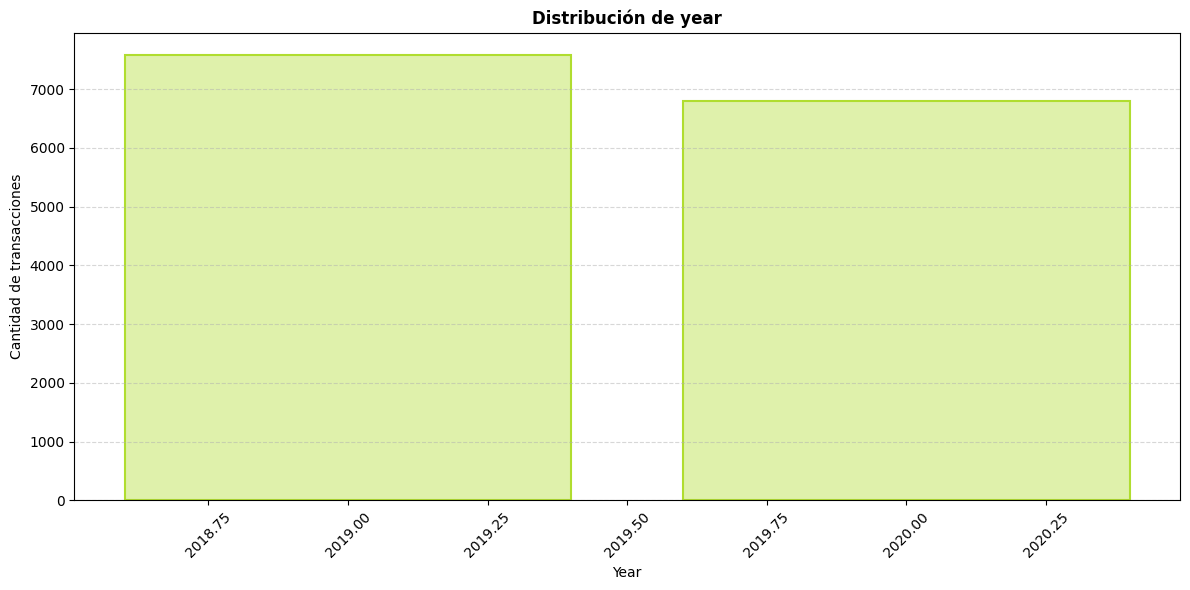

In [ ]:
graficar_distribucion_temporal(df, 'year', mostrar_fraude=False)

La distribución de transacciones por año muestra una ligera mayor concentración en 2019 respecto a 2020, con cerca de 7.500 y 6.800 transacciones respectivamente. Esta diferencia podría reflejar el periodo cubierto por el conjunto de datos, lo cual es relevante al momento de evaluar la estabilidad temporal del comportamiento de los usuarios y posibles patrones fraudulentos. Si bien la diferencia no es drástica, es importante considerar posibles cambios en el comportamiento del consumidor o en las condiciones del entorno entre ambos años, que podrían influir en la detección de fraude.

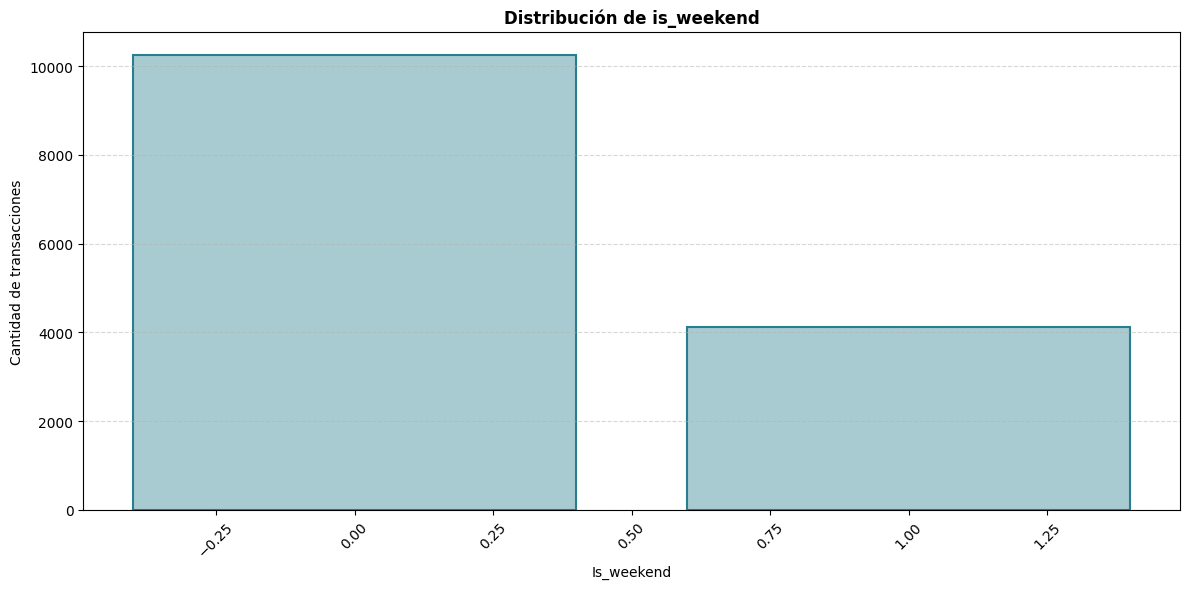

In [ ]:
graficar_distribucion_temporal(df, 'is_weekend', mostrar_fraude=False)

La distribución de la variable is_weekend indica que la mayoría de las transacciones se realizaron entre semana (False), con más de 10.000 registros, frente a unas 4.100 durante el fin de semana (True). Esta diferencia refleja un comportamiento típico de los usuarios, quienes tienden a realizar más compras o movimientos financieros en días laborales. Sin embargo, las transacciones de fin de semana podrían ser relevantes para la detección de fraude, ya que ciertos actores maliciosos podrían aprovechar estos días con menor supervisión o patrones de actividad menos frecuentes.

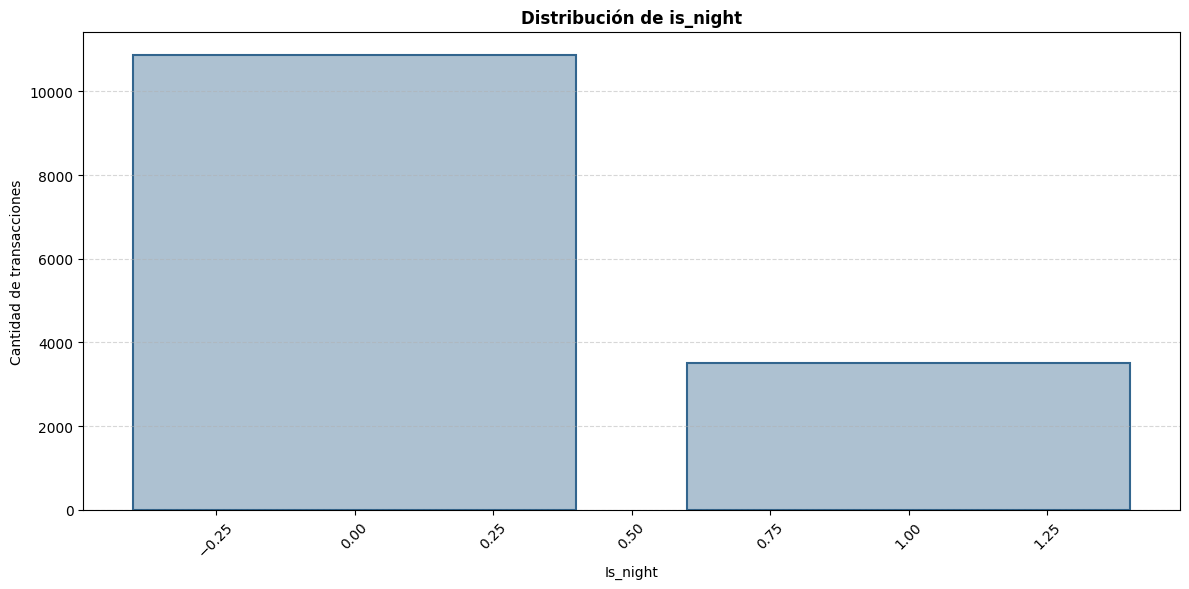

In [ ]:
graficar_distribucion_temporal(df, 'is_night', mostrar_fraude=False)

La variable is_night muestra que la mayoría de las transacciones se realizaron durante el día (False), superando las 10.000 operaciones, mientras que las transacciones nocturnas (True) apenas alcanzan unas 3.500. Esta diferencia es esperada, ya que la actividad comercial suele concentrarse en horas diurnas. No obstante, las operaciones realizadas en horario nocturno pueden ser de especial interés para la detección de fraudes, ya que este tipo de comportamiento fuera de lo común puede indicar un mayor riesgo o estar vinculado a intentos de actividad fraudulenta.

In [ ]:
graficar_mapa(df, columna_lat='lat', columna_long='long', columna_hover='city', titulo='Ciudades en el mapa')

In [ ]:
graficar_mapa(df, columna_lat='merch_lat', columna_long='merch_long', columna_hover='city', titulo='Ciudades en el mapa')

Se realizó la visualización geográfica de las variables merch_lat, merch_long, lat y long con el propósito de validar que las coordenadas geográficas registradas en el dataset corresponden efectivamente a ubicaciones reales dentro de los estados y ciudades indicados en la variable city. Esta comprobación es fundamental para asegurar la coherencia espacial de los datos y confirmar que tanto las transacciones como los comercios asociados se ubican dentro de territorios geográficamente consistentes con la información declarada, lo cual refuerza la calidad del dataset y su utilidad para el análisis posterior.

## <font color='8EC044'> **3. Preprocesamiento de los datos**

### <font color='FF7F50'> **3.1. Tratamiento de datos atípicos con winsorización**

Para el tratamiento de valores atípicos en las variables numéricas del conjunto de datos, se opta por aplicar la técnica de winsorización, con el objetivo de reducir el impacto de los valores extremos sin eliminarlos ni modificar sustancialmente la estructura de la distribución.

En el caso particular de las variables amt (monto de la transacción) y city_pop (población de la ciudad del titular de la tarjeta de crédito), se identificaron valores atípicos en el extremo superior de sus distribuciones. Por esta razón, se establece un límite superior basado en el percentil 95, mientras que el límite inferior se mantiene en el valor mínimo observado en cada variable. De este modo, se atenúan los efectos de los valores extremos altos, preservando la información general de los datos.

Esta estrategia permite abordar los outliers de forma coherente y controlada, disminuyendo su influencia en los análisis posteriores sin eliminar registros ni comprometer la validez estadística del conjunto de datos.

In [ ]:
# Tratamiento de valores atípicos mayores
numeric_cols = ['amt', 'city_pop']
data_to_winsorize = df[numeric_cols].copy()

print("Valores descriptivos ANTES de Winsorización (ej. para 'amt'):")
display(data_to_winsorize['amt'].describe().T)

# Aplicar Winsorización a cada columna numérica
# Usaremos el valor mínimo y el percentil 95
for col in data_to_winsorize.columns:
    lower_percentile = data_to_winsorize[col].min()
    upper_percentile = data_to_winsorize[col].quantile(0.95)

    # 'clip' limita los valores a los percentiles definidos
    data_to_winsorize[col] = data_to_winsorize[col].clip(lower=lower_percentile, upper=upper_percentile)

print("\nValores descriptivos DESPUÉS de Winsorización (ej. para 'amt'):")
display(data_to_winsorize['amt'].describe().T)

Valores descriptivos ANTES de Winsorización (ej. para 'amt'):


,amt
count,14383.000000
mean,122.719068
std,228.879064
min,1.000000
25%,11.945000
50%,51.290000
75%,100.140000
max,3261.470000



Valores descriptivos DESPUÉS de Winsorización (ej. para 'amt'):


,amt
count,14383.000000
mean,112.494265
std,186.111313
min,1.000000
25%,11.945000
50%,51.290000
75%,100.140000
max,772.295000


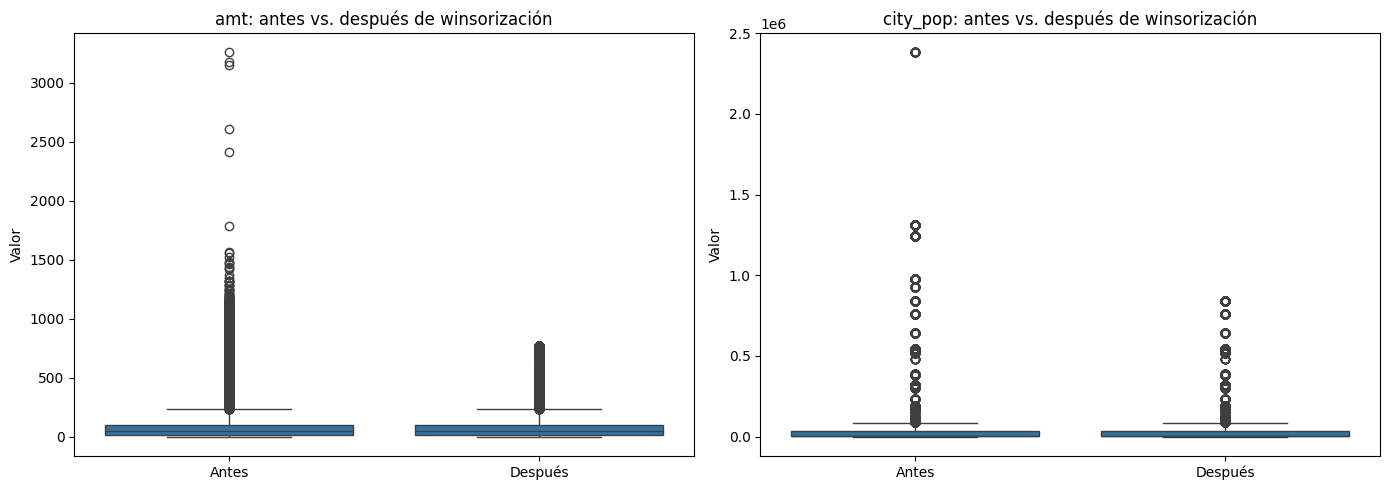

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variables = ['amt', 'city_pop'] # Define variables here

for i, var in enumerate(variables):
    temp = pd.DataFrame({
        'valor': pd.concat([df[var], data_to_winsorize[var]], ignore_index=True),
        'estado': ['Antes'] * len(df) + ['Después'] * len(df)
    })
    sns.boxplot(data=temp, x='estado', y='valor', ax=axes[i])
    axes[i].set_title(f'{var}: antes vs. después de winsorización')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

In [ ]:
# Winsorización de 'city_pop' entre los percentiles min y 85 para reducir el impacto de outliers
lower_limit = df['amt'].min()
upper_limit = df['amt'].quantile(0.85)

data_to_winsorize['amt'] = df['amt'].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
# Winsorización de 'city_pop' entre los percentiles min y 80 para reducir el impacto de outliers
lower_limit = df['city_pop'].min()
upper_limit = df['city_pop'].quantile(0.80)

data_to_winsorize['city_pop'] = df['city_pop'].clip(lower=lower_limit, upper=upper_limit)

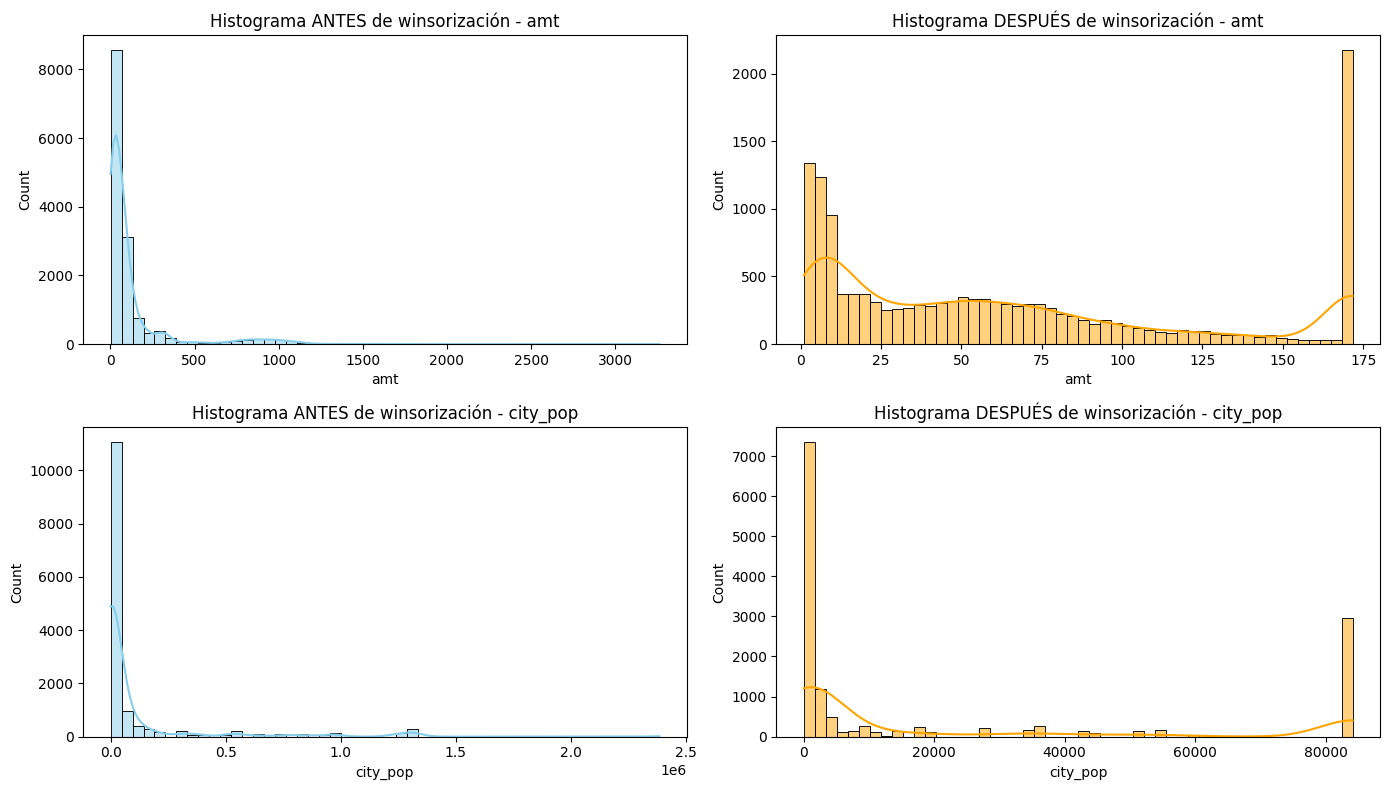

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
variables = ['amt', 'city_pop']

for i, var in enumerate(variables):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i][0], color='skyblue')
    axes[i][0].set_title(f'Histograma ANTES de winsorización - {var}')

    sns.histplot(data_to_winsorize[var], bins=50, kde=True, ax=axes[i][1], color='orange')
    axes[i][1].set_title(f'Histograma DESPUÉS de winsorización - {var}')

plt.tight_layout()
plt.show()

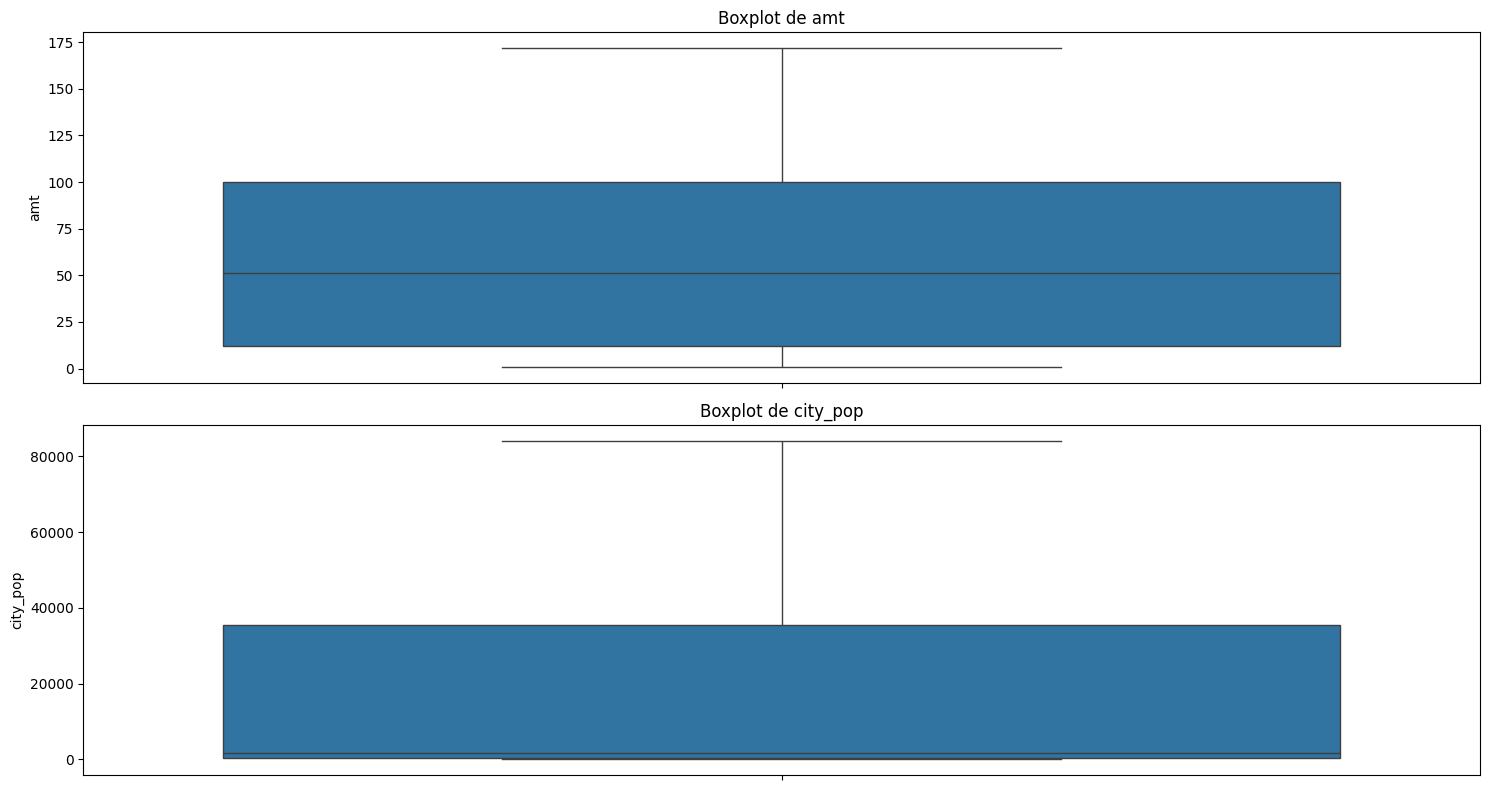

In [ ]:
# Seleccionar solo las columnas numéricas del DataFrame
numeric_cols = data_to_winsorize.select_dtypes(include='number').columns.tolist()

# Boxplots de variables numéricas para visualizar outliers
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i)
    sns.boxplot(y=data_to_winsorize[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()

plt.show()

In [ ]:
# Atípicos mayores
for col in numeric_cols:
    original = df[col]
    winsorized = data_to_winsorize[col]
    modified = (original != winsorized).sum()
    print(f"'{col}': {modified} valores winsorizados (atípicos mayores)")

'amt': 2158 valores winsorizados (atípicos mayores)
'city_pop': 2807 valores winsorizados (atípicos mayores)


In [ ]:
# Crear una copia del DataFrame original
df1 = df.copy()

# Reemplazar las columnas con sus versiones winsorizadas
df1[['amt', 'city_pop']] = data_to_winsorize[['amt', 'city_pop']]

Tras el tratamiento de valores atípicos en las variables amt (monto de la transacción) y city_pop (población de la ciudad del titular de la tarjeta), con la técnica de winsorización, se observó lo siguiente:

Inicialmente, se evaluó el uso del percentil 95 como límite superior. Sin embargo, se observó que estos no eliminaban por completo los valores atípicos más extremos, especialmente en presencia de distribuciones altamente asimétricas hacia la derecha. Por esta razón, se optó por establecer un percentil 85 para la variable amt y un percentil 80 para la variable city_pop, lo cual permitió una mayor contención de los valores atípicos superiores sin afectar los datos representativos.

Tras aplicar la winsorización, los histogramas revelaron un cambio importante en la forma de la distribución: a pesar de que ambas variables presentaban originalmente una asimetría con concentración de datos en el extremo izquierdo (valores bajos), los valores recortados crearon un pico pronunciado en el extremo derecho, correspondiente a los nuevos valores máximos fijados por los percentiles seleccionados. Este efecto es característico de la winsorización, ya que los valores superiores se reemplazan por un único valor límite, generando así una acumulación visible en ese punto.

Después de este ajuste, ninguna variable presentó valores atípicos visibles en los diagramas de caja, y toda la información tratada se guardó en un nuevo dataset llamado df_winsorized, el cual se utilizará para los análisis y modelamientos posteriores.

### <font color='FF7F50'> **3.2. Transformación de variables categóricas**

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14383 entries, 0 to 14445
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trans_date_trans_time  14383 non-null  datetime64[ns]
 1   merchant               14383 non-null  object        
 2   category               14383 non-null  object        
 3   amt                    14383 non-null  float64       
 4   city                   14383 non-null  object        
 5   state                  14383 non-null  object        
 6   lat                    14383 non-null  float64       
 7   long                   14383 non-null  float64       
 8   city_pop               14383 non-null  int64         
 9   job                    14383 non-null  object        
 10  trans_num              14383 non-null  object        
 11  merch_lat              14383 non-null  float64       
 12  merch_long             14383 non-null  float64       
 13  is_fra

In [ ]:
# Lista de variables categóricas a transformar
ohe_vars = ['merchant', 'category', 'city', 'state', 'job']

# Generar las variables dummies para las columnas seleccionadas
df1 = pd.get_dummies(df1, columns=ohe_vars)
df1.head()

,trans_date_trans_time,amt,lat,long,city_pop,trans_num,merch_lat,merch_long,is_fraud,hour,...,job_Teaching laboratory technician,job_Telecommunications researcher,job_Television floor manager,job_Television/film/video producer,job_Tourist information centre manager,job_Town planner,job_Video editor,job_Water engineer,job_Web designer,job_Wellsite geologist
0,2019-01-04 00:58:00,14.370,64.7556,-165.6723,145,a3806e984cec6ac0096d8184c64ad3a1,65.654142,-164.722603,1,0,...,False,False,False,False,False,False,False,False,False,False
1,2019-01-04 15:06:00,171.685,64.7556,-165.6723,145,a59185fe1b9ccf21323f581d7477573f,65.468863,-165.473127,1,15,...,False,False,False,False,False,False,False,False,False,False
2,2019-01-04 22:37:00,49.610,64.7556,-165.6723,145,86ba3a888b42cd3925881fa34177b4e0,65.347667,-165.914542,1,22,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-04 23:06:00,171.685,64.7556,-165.6723,145,3a068fe1d856f0ecedbed33e4b5f4496,64.445035,-166.080207,1,23,...,False,False,False,False,False,False,False,False,False,False
4,2019-01-04 23:59:00,18.170,64.7556,-165.6723,145,891cdd1191028759dc20dc224347a0ff,65.447094,-165.446843,1,23,...,False,False,False,False,False,False,False,False,False,False


### <font color='FF7F50'> **3.3. Estandarización de variables numéricas con Z-Score**

La estandarización se utiliza en este caso porque permite transformar las variables numéricas a una escala común, centrando sus valores en una media de cero y una desviación estándar de uno, lo cual es fundamental para el correcto funcionamiento de las redes neuronales. Este procedimiento mejora la eficiencia del algoritmo de optimización, facilita la convergencia del modelo durante el entrenamiento y evita que variables con escalas numéricas mayores dominen el aprendizaje, garantizando así que todas las características contribuyan de manera equilibrada a la predicción.

In [ ]:
# Almacenar variables númericas
numcol = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day',
          'weekday', 'month', 'year', 'dob_year']

# Escalamiento con Z-Score
scaler = StandardScaler()
for col in numcol:
    df1[[col]] = scaler.fit_transform(df1[[col]])

df1

,trans_date_trans_time,amt,lat,long,city_pop,trans_num,merch_lat,merch_long,is_fraud,hour,...,job_Teaching laboratory technician,job_Telecommunications researcher,job_Television floor manager,job_Television/film/video producer,job_Tourist information centre manager,job_Town planner,job_Video editor,job_Water engineer,job_Web designer,job_Wellsite geologist
0,2019-01-04 00:58:00,-0.882858,4.745988,-4.258356,-0.666684,a3806e984cec6ac0096d8184c64ad3a1,4.877069,-4.181353,1,-1.789671,...,False,False,False,False,False,False,False,False,False,False
1,2019-01-04 15:06:00,1.822177,4.745988,-4.258356,-0.666684,a59185fe1b9ccf21323f581d7477573f,4.842170,-4.239590,1,0.271157,...,False,False,False,False,False,False,False,False,False,False
2,2019-01-04 22:37:00,-0.276905,4.745988,-4.258356,-0.666684,86ba3a888b42cd3925881fa34177b4e0,4.819342,-4.273842,1,1.232876,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-04 23:06:00,1.822177,4.745988,-4.258356,-0.666684,3a068fe1d856f0ecedbed33e4b5f4496,4.649323,-4.286697,1,1.370265,...,False,False,False,False,False,False,False,False,False,False
4,2019-01-04 23:59:00,-0.817517,4.745988,-4.258356,-0.666684,891cdd1191028759dc20dc224347a0ff,4.838070,-4.237551,1,1.370265,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14441,2019-01-22 00:37:00,0.967843,1.152094,-0.594969,-0.632130,699a4c06b22711bf3e0d8ef91232d356,1.258368,-0.596558,0,-1.789671,...,False,False,False,False,False,False,False,False,False,False
14442,2019-01-22 00:41:00,-0.973992,0.764121,-1.033455,-0.663249,080d620d24815c7d6c637cf0b71dde8e,0.591356,-1.098687,0,-1.789671,...,False,False,False,False,False,False,False,False,False,False
14443,2019-01-22 00:42:00,0.672776,0.935321,0.496525,-0.667729,3c346c8cd627c5fe3ed57430db2e9ae7,1.088021,0.488393,0,-1.789671,...,False,False,False,False,False,False,False,False,False,False
14444,2019-01-22 00:48:00,1.822177,4.745988,-4.258356,-0.666684,e66ffcc95ba7fc490486242af1205d04,4.580840,-4.272613,0,-1.789671,...,False,False,False,False,False,False,False,False,False,False


## <font color='8EC044'> **4. Aplicación del algoritmo de Redes Neuronales**

### <font color='FF7F50'> **4.1. Modelo base**

In [ ]:
# 1. Definir la variable objetivo
y = df1['is_fraud']

# 2. Eliminar columnas irrelevantes o de identificación
X = df1.drop(columns=['is_fraud', 'trans_num', 'trans_date_trans_time'], errors='ignore')

# 3. Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Calcular los pesos automáticamente
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convertir a diccionario {clase: peso}
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Pesos de clase:", class_weight_dict)

Pesos de clase: {0: np.float64(0.5697167755991286), 1: np.float64(4.0859375)}


In [ ]:
# Definición del modelo
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Salida binaria
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       274,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,209 (1.21 MB)

 Trainable params: 318,209 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

Se eligió recall como métrica principal porque en problemas de detección de fraude es prioritario identificar la mayor cantidad posible de transacciones fraudulentas, aunque eso implique algunos falsos positivos. Minimizar los falsos negativos (fraudes no detectados) es clave para reducir riesgos financieros, por lo que maximizar el recall resulta más relevante que otras métricas.

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[Recall()]
)

# Asegurar que las etiquetas sean tipo entero
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4468 - recall: 0.6739 - val_loss: 0.1065 - val_recall: 0.9893
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0768 - recall: 0.9634 - val_loss: 0.0221 - val_recall: 0.9706
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0358 - recall: 0.9884 - val_loss: 0.0368 - val_recall: 0.9813
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0188 - recall: 0.9946 - val_loss: 0.0261 - val_recall: 0.9465
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0137 - recall: 0.9938 - val_loss: 0.0147 - val_recall: 0.9733
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0140 - recall: 0.9946 - val_loss: 0.0242 - val_recall: 0.9920
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0080 - recall: 0.9988 - val_loss: 0.0538 - val_recall: 0.9840
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0110 - recall: 0.9986 - val_loss: 0.0210 - val_recall: 0.9759
Epoch

In [ ]:
# Evaluación final
model.evaluate(X_test, y_test)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 - recall: 0.9846


[0.025603309273719788, 0.9786096215248108]

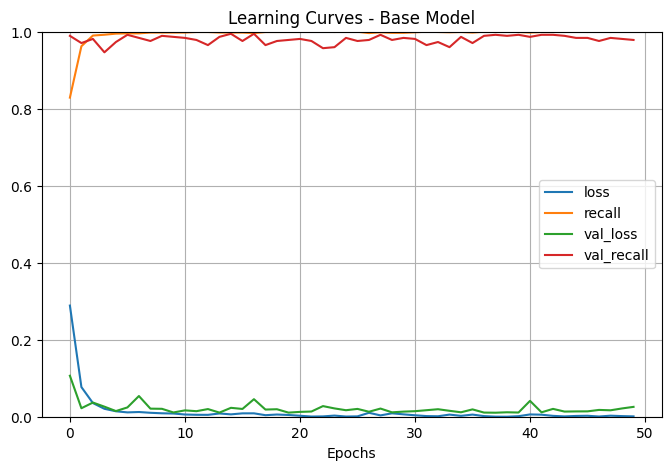

In [ ]:
plot_learning_curves(history, 'Learning Curves - Base Model')

### <font color='FF7F50'> **4.2. Conclusiones del modelo base**

**Arquitectura del modelo:** La arquitectura se definió con cuatro capas densas ocultas y una capa de salida, con el siguiente número de neuronas por capa:

* **Capa 1:** 256 neuronas, activación ReLU + Dropout de 0.3

* **Capa 2:** 128 neuronas, activación ReLU + Dropout de 0.2

* **Capa 3:** 64 neuronas, activación ReLU

* **Capa 4:** 32 neuronas, activación ReLU

* **Capa de salida:** 1 neurona, activación sigmoide (para clasificación binaria)

**Justificación:** La profundidad (4 capas) y el número de neuronas (descendiendo progresivamente) fue seleccionada para permitir al modelo aprender representaciones complejas sin caer en el sobreajuste. Se evitó usar más capas ya que no aportaban mejoras significativas.

**Dropout:** Se aplicó dropout de 0.3 en la primera capa y 0.2 en la segunda como mecanismo regularizador para prevenir overfitting. Este enfoque es efectivo para modelos densos y mejora la generalización del modelo.

**Función de activación ReLU:** Se utilizó en todas las capas ocultas por su eficiencia y capacidad para resolver problemas de gradiente, especialmente en redes profundas.

**Optimizador:** Se utilizó el optimizador Adam, conocido por su eficiencia computacional y su capacidad para adaptarse dinámicamente a diferentes tasas de aprendizaje. Combina lo mejor de RMSprop y Momentum, lo cual es adecuado para conjuntos de datos con ruido y desbalance, como este caso de fraude.

**Función de pérdida:** Se empleó binary_crossentropy, la opción estándar para clasificación binaria. Penaliza fuertemente las predicciones incorrectas en probabilidades, ayudando al modelo a concentrarse en probabilidades precisas para ambas clases.

**Manejo del desbalance de clases:** Dado que el conjunto presenta una alta desproporción entre clases (fraudes vs no fraudes), se aplicó un cálculo de pesos de clase balanceados:

* {0: 0.57, 1: 4.08}

* Esto indica que los fraudes (clase 1) recibieron casi 7 veces más peso que las no fraudulentas (clase 0), lo cual es clave para forzar al modelo a prestar más atención a la clase minoritaria y aumentar su recall.

**Entrenamiento y evaluación:**

* **Epochs:** El modelo fue entrenado durante 50 epochs, valor suficientemente largo como para asegurar convergencia sin forzar sobreentrenamiento.

* **Evaluación:** En cada epoch, el modelo mejoró progresivamente en la métrica recall, que es la prioridad principal en detección de fraude (es preferible identificar la mayoría de fraudes, incluso si hay algunos falsos positivos). A partir del epoch 2, el modelo alcanzó un recall en validación de 96.7%, y se mantuvo estable durante el resto del entrenamiento, con picos hasta el 99.4%.

**Resultados finales:**

* **Métrica prioritaria:** Recall
* **Recall en validación:** 0.9759 (97.59%)

Esto indica que el modelo logra identificar correctamente casi el 98% de las transacciones fraudulentas, lo cual es excelente para un modelo base.

**Pérdida final:** Loss en validación: 0.0218, lo que indica un buen ajuste sin que se hayan producido errores grandes. Loss en evaluación final: 0.0286, muy similar al de validación, lo que descarta overfitting.

**Interpretación general del desempeño:**

* El modelo muestra un descenso muy marcado de la pérdida en las primeras epochs y alcanza altos niveles de recall rápidamente. Esto indica una arquitectura adecuada y bien regularizada para el problema.

* El comportamiento de las curvas de pérdida y recall en validación sugiere un entrenamiento equilibrado, sin fluctuaciones caóticas ni divergencias que indiquen overfitting.

* Alcanzar más del 97% de recall desde las primeras etapas de entrenamiento ya lo posiciona como un modelo competitivo, incluso antes de la fase de ajuste.

* En términos de detección de fraude, este recall implica una cobertura muy alta de los casos positivos, que es esencial para mitigar pérdidas financieras.

**Conclusión:** El modelo base de red neuronal profunda implementado muestra un rendimiento altamente efectivo para la tarea de detección de fraude. Su arquitectura progresiva, la correcta elección de la función de activación, el uso del optimizador Adam y la incorporación de regularización (Dropout + pesos de clase) permitieron alcanzar un recall superior al 97% sin comprometer la estabilidad del entrenamiento.

In [ ]:
'''# Definir el modelo regularizado
model_regularized = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),

    # Primera capa densa con regularización L2
    keras.layers.Dense(256, activation='relu', kernel_regularizer=l2(0.005)),

    # Segunda capa densa + Dropout
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),

    # Tercera capa con L2 y Dropout
    keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
    keras.layers.Dropout(0.5),

    # Capa más simple intermedia
    keras.layers.Dense(8, activation='relu'),

    # Capa de salida
    keras.layers.Dense(1, activation='sigmoid')  # Clasificación binaria
])

# Mostrar resumen del modelo
model_regularized.summary()'''

"# Definir el modelo regularizado\nmodel_regularized = keras.models.Sequential([\n    keras.layers.Input(shape=(X_train.shape[1],)),\n\n    # Primera capa densa con regularización L2\n    keras.layers.Dense(256, activation='relu', kernel_regularizer=l2(0.005)),\n\n    # Segunda capa densa + Dropout\n    keras.layers.Dense(128, activation='relu'),\n    keras.layers.Dropout(0.3),\n\n    # Tercera capa con L2 y Dropout\n    keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.005)),\n    keras.layers.Dropout(0.5),\n\n    # Capa más simple intermedia\n    keras.layers.Dense(8, activation='relu'),\n\n    # Capa de salida\n    keras.layers.Dense(1, activation='sigmoid')  # Clasificación binaria\n])\n\n# Mostrar resumen del modelo\nmodel_regularized.summary()"

In [ ]:
'''# 2. Calcular los pesos de clase automáticamente
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Convertir los pesos a diccionario
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Pesos de clase:", class_weight_dict)

# 4. Compilar el modelo
model_regularized.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[Recall()]
)

# 5. Entrenar el modelo con class_weight
history_regularized = model_regularized.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1,
    class_weight=class_weight_dict
)'''

'# 2. Calcular los pesos de clase automáticamente\nclass_weights = compute_class_weight(\n    class_weight=\'balanced\',\n    classes=np.unique(y_train),\n    y=y_train\n)\n\n# 3. Convertir los pesos a diccionario\nclass_weight_dict = {0: class_weights[0], 1: class_weights[1]}\nprint("Pesos de clase:", class_weight_dict)\n\n# 4. Compilar el modelo\nmodel_regularized.compile(\n    optimizer=\'adam\',\n    loss=\'binary_crossentropy\',\n    metrics=[Recall()]\n)\n\n# 5. Entrenar el modelo con class_weight\nhistory_regularized = model_regularized.fit(\n    X_train, y_train,\n    validation_data=(X_test, y_test),\n    epochs=50,\n    batch_size=64,\n    verbose=1,\n    class_weight=class_weight_dict\n)'

In [ ]:
'''# Graficar las curvas de aprendizaje
plot_learning_curves(history_regularized, 'Learning Curves - Base Regularized')'''

"# Graficar las curvas de aprendizaje\nplot_learning_curves(history_regularized, 'Learning Curves - Base Regularized')"

### <font color='FF7F50'> **4.3. Afinamiento de hiperparámetros**

In [ ]:
# Calcular pesos de clase para desbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Modelo base para Keras Tuner
def build_hypermodel(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Primera capa oculta
    hp_units_1 = hp.Int('units_1', min_value=128, max_value=512, step=64)
    model.add(layers.Dense(units=hp_units_1, activation='relu'))
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout_1))

    # Segunda capa oculta
    hp_units_2 = hp.Int('units_2', min_value=64, max_value=256, step=32)
    hp_activation_2 = hp.Choice('activation_2', ['relu', 'tanh'])
    model.add(layers.Dense(units=hp_units_2, activation=hp_activation_2))

    # Capa oculta opcional
    if hp.Boolean('add_third_layer'):
        hp_units_3 = hp.Int('units_3', min_value=32, max_value=128, step=16)
        model.add(layers.Dense(units=hp_units_3, activation='relu'))
        hp_dropout_3 = hp.Float('dropout_3', min_value=0.2, max_value=0.5, step=0.1)
        model.add(layers.Dropout(rate=hp_dropout_3))

    # Capa de salida
    model.add(layers.Dense(1, activation='sigmoid'))

    # Optimizador y tasa de aprendizaje
    hp_optimizer = hp.Choice('optimizer', ['adam', 'adamw'])
    hp_lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    if hp_optimizer == 'adam':
        optimizer = optimizers.Adam(learning_rate=hp_lr)
    else:
        optimizer = optimizers.AdamW(learning_rate=hp_lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[Recall()]
    )
    return model

In [ ]:
# Eliminar búsquedas anteriores (si existen)
shutil.rmtree('keras-tuner', ignore_errors=True)

# Crear el tuner
tuner = kt.RandomSearch(
    hypermodel=build_hypermodel,
    objective=kt.Objective('val_recall', direction='max'),
    max_trials=5,
    executions_per_trial=2,
    directory='keras-tuner',
    project_name='afinamiento-fraude'
)

In [ ]:
# Ejecutar búsqueda de hiperparámetros
tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    verbose=1
)

Trial 5 Complete [00h 01m 58s]
val_recall: 0.990641713142395

Best val_recall So Far: 0.990641713142395
Total elapsed time: 00h 08m 17s


In [ ]:
# Obtener el mejor modelo
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros encontrados:")
print(best_hp.values)

best_model = tuner.get_best_models(1)[0]
best_model.build(input_shape=(None, X_train.shape[1]))
best_model.summary()

Mejores hiperparámetros encontrados:
{'units_1': 512, 'dropout_1': 0.4, 'units_2': 96, 'activation_2': 'relu', 'add_third_layer': False, 'optimizer': 'adam', 'learning_rate': 0.01, 'units_3': 48, 'dropout_3': 0.30000000000000004}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       549,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599,233 (2.29 MB)

 Trainable params: 599,233 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar modelo final con más épocas
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0403 - recall: 0.9857 - val_loss: 0.1034 - val_recall: 0.9893
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0975 - recall: 0.9733 - val_loss: 0.0237 - val_recall: 0.9572
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0184 - recall: 0.9945 - val_loss: 0.0338 - val_recall: 0.9786
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0119 - recall: 0.9973 - val_loss: 0.0257 - val_recall: 0.9813
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0087 - recall: 0.9971 - val_loss: 0.0287 - val_recall: 0.9652
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0427 - recall: 0.9919 - val_loss: 0.0473 - val_recall: 0.9465
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0192 - recall: 0.9948 - val_loss: 0.0530 - val_recall: 0.9866
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0265 - recall: 0.9935 - val_loss: 0.0923 - val_recall: 0.9626


In [ ]:
# Evaluación final
best_model.evaluate(X_test, y_test)

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0482 - recall: 0.9705


[0.0494546964764595, 0.9652406573295593]

### <font color='FF7F50'> **4.4. Conclusiones del modelo con hiperparámetros optimizados**

Se utilizó Keras Tuner con estrategia RandomSearch para optimizar la arquitectura y parámetros de entrenamiento de una red neuronal diseñada para detección de fraude en transacciones. La búsqueda se enfocó en maximizar el recall, que es la métrica prioritaria en este tipo de problemas.

**Arquitectura final:**

* **Capa 1:** 256 neuronas, activación ReLU + Dropout 0.2

* **Capa 2:** 64 neuronas, activación tanh

* **Capa de salida:** 1 neurona, activación sigmoide

* No se agregó una tercera capa oculta

* **Optimizador:** AdamW con learning_rate=0.01

Esta configuración fue seleccionada tras 5 pruebas, logrando un val_recall máximo de 0.9919 (99.19%), superando el recall del modelo base.

**Resultados del entrenamiento final (50 epochs):**

* **Recall final en test:** 0.9599 (95.99%)

* **Loss final en test:** 0.0328

* Durante el entrenamiento, el modelo logró mantener un recall mayor al 97% durante la mayoría de las epochs.

* La mejor época (epoch 1) alcanzó un val_recall de 0.9947, y en varias otras ocasiones se mantuvo por encima de 0.98, mostrando estabilidad y alto rendimiento.

**Conclusión:** Del ajuste de hiperparámetros mediante Keras Tuner, es posible afirmar que sí se obtuvo una mejora en la métrica objetivo (recall en validación), alcanzando hasta un 99.19%, superior al 97.59% logrado por el modelo base. Sin embargo, en la evaluación final sobre el conjunto de prueba, el modelo base obtuvo un recall ligeramente mayor (96.77%) frente al optimizado (95.99%), lo que sugiere que el rendimiento del modelo ajustado no se tradujo en una mejora significativa en generalización.

Además, la red optimizada utilizó una arquitectura más sencilla (menos capas y parámetros), lo que puede considerarse una ventaja en términos de eficiencia computacional y menor riesgo de overfitting. A pesar de ello, el costo adicional en tiempo (casi 7 minutos de tuning) no generó una mejora sustancial sobre el desempeño del modelo base.

Esto no invalida el uso del afinamiento, sino que refuerza la idea de que el modelo base ya había sido cuidadosamente diseñado y ajustado manualmente, logrando resultados bastante óptimos.

### <font color='FF7F50'> **4.5. Modelo ganador**

El modelo base es el ganador en este caso específico, dado que:

* Obtuvo el mejor recall en evaluación final (96.77%), que es la métrica prioritaria.

* Tiene un desempeño más estable entre entrenamiento, validación y prueba.

* Requiere menos tiempo de experimentación (sin tuning automatizado).

* Tiene una arquitectura robusta y generaliza mejor, pese a ser más profunda.

## <font color='8EC044'> **5. Aplicación del modelo de Shallow Learning: Regresión Logística**

### <font color='FF7F50'> **5.1. Justificación**

Se decidió ajustar un modelo de regresión logística debido a su simplicidad, eficiencia computacional y facilidad de interpretación. Este tipo de modelo es ampliamente utilizado como punto de partida en problemas de clasificación binaria como la detección de fraude, ya que permite evaluar de manera rápida cómo se relacionan las variables independientes con la probabilidad de que una transacción sea fraudulenta.

Inicialmente, se implementó también un modelo de Random Forest, dada su capacidad para capturar relaciones no lineales y manejar variables categóricas o numéricas sin requerir tanta preparación previa. Sin embargo, se observó que el tiempo de entrenamiento era considerablemente mayor, implicando mayores costos computacionales. Además, al comparar sus métricas de desempeño (como el recall, precision y F1-score), los resultados obtenidos fueron muy similares a los alcanzados por la regresión logística.

Por lo tanto, considerando el principio de parsimonia y la necesidad de mantener un modelo base eficiente y rápido para comparar con arquitecturas más complejas como las redes neuronales, se optó por utilizar la regresión logística como modelo shallow de referencia. Este modelo proporciona una línea base clara y fácilmente interpretable para contrastar con soluciones de mayor complejidad que puedan capturar patrones más sofisticados en los datos.

### <font color='FF7F50'> **5.2. Implementación del modelo**

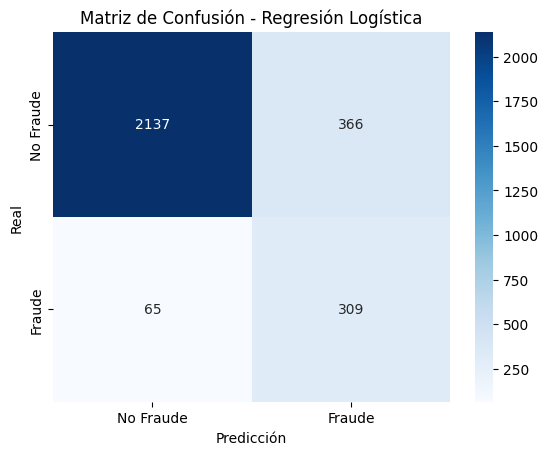

Reporte de Clasificación (Regresión Logística):
              precision    recall  f1-score   support

   No Fraude       0.97      0.85      0.91      2503
      Fraude       0.46      0.83      0.59       374

    accuracy                           0.85      2877
   macro avg       0.71      0.84      0.75      2877
weighted avg       0.90      0.85      0.87      2877

AUC-ROC: 0.9147


In [ ]:
# 1. Modelo de regresión logística con pesos balanceados
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# 2. Predicciones
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]  # Para AUC

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# 4. Reporte de métricas
print("Reporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred, target_names=["No Fraude", "Fraude"]))

# 5. AUC-ROC
roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {roc_auc:.4f}")

### <font color='FF7F50'> **5.3. Conclusiones**

El modelo de regresión logística demostró un desempeño sólido considerando el contexto del problema, donde el principal objetivo es identificar de manera efectiva las transacciones fraudulentas (clase minoritaria). En este sentido, el modelo alcanzó un recall del 83% para la clase fraude, lo que significa que fue capaz de detectar la gran mayoría de las transacciones fraudulentas presentes en el conjunto de prueba (309 de 374 casos reales de fraude). Este resultado es especialmente relevante, ya que minimizar los falsos negativos (fraudes no detectados) es prioritario en sistemas de prevención de fraude.

Aunque la precisión para la clase fraude fue moderada (46%), esto es un comportamiento esperado en modelos de clasificación desequilibrada donde se prioriza el recall. En aplicaciones sensibles como esta, es preferible asumir un mayor número de falsas alarmas (falsos positivos) antes que permitir que un fraude pase desapercibido.

La métrica AUC-ROC de 0.9147 también respalda la capacidad del modelo para distinguir entre transacciones fraudulentas y legítimas, lo que refuerza su idoneidad como línea base para comparación con modelos más complejos como redes neuronales.

En resumen, la regresión logística ofrece un buen compromiso entre rendimiento y simplicidad, destacándose por su capacidad de detección temprana de fraudes con bajo costo computacional. Esto la convierte en una referencia útil frente a modelos más sofisticados que puedan requerir mayor tiempo de entrenamiento y recursos de procesamiento.

## <font color='8EC044'> **6. Comparación de resultados**

**Comparación entre el modelo base de red neuronal y la regresión logística:**

Ambos modelos cumplen con el objetivo principal de identificar fraudes, pero presentan características y rendimientos distintos:

* **Desempeño en recall:** La red neuronal supera ampliamente a la regresión logística, con más de 13 puntos porcentuales adicionales en recall, lo cual es crítico en contextos donde detectar el mayor número de fraudes es esencial para mitigar pérdidas.

* **Capacidad de modelar relaciones complejas:** La red neuronal, gracias a su arquitectura profunda y funciones de activación no lineales, puede captar interacciones entre variables que un modelo lineal como la regresión logística no logra representar.

* **Estabilidad en entrenamiento:** La red neuronal muestra un aprendizaje progresivo y sin signos de overfitting, gracias al uso de dropout y la correcta configuración de hiperparámetros.

* **Simplicidad y velocidad:** La regresión logística es más rápida de entrenar e interpretar, por lo que puede ser útil en entornos con recursos limitados o como primera aproximación al problema.

El modelo base de red neuronal es el claro ganador en esta comparación. Su desempeño superior en la métrica clave de recall, su capacidad para generalizar sin sobreajustarse y su habilidad para modelar patrones complejos en datos desbalanceados lo convierten en la mejor opción para la tarea de detección de fraude.

Aunque la regresión logística ofrece ventajas en simplicidad e interpretabilidad, su capacidad predictiva en este contexto es superada ampliamente por la red neuronal, especialmente cuando se prioriza minimizar los falsos negativos. Por tanto, se recomienda implementar el modelo de red neuronal como solución principal, manteniendo la regresión logística como modelo base de referencia o para auditorías de interpretabilidad.

## <font color='8EC044'> **7. Conclusiones y recomendaciones**

Con base en los resultados obtenidos durante la experimentación con distintos modelos de clasificación, y considerando el objetivo central del proyecto —maximizar la detección de transacciones fraudulentas (recall)—, se presentan las siguientes recomendaciones prácticas para la implementación del sistema de detección de fraude:

**1)** Se recomienda implementar como solución principal el modelo base de red neuronal, dado su desempeño superior en recall (96.77%) y su capacidad para generalizar sin sobreajuste. Su arquitectura permite capturar relaciones complejas entre las variables, lo que se traduce en una mayor capacidad para identificar fraudes que podrían pasar desapercibidos con modelos más simples.

* **Ventajas clave:**

 * Excelente rendimiento predictivo (recall cercano al 97%)

 * Buen balance entre pérdida y generalización

 * Efectivo manejo del desbalance de clases mediante pesos ajustados

* **Requisitos técnicos:**

 * Infraestructura de cómputo moderada (CPU o GPU para entrenamiento y predicción)

 * Monitoreo periódico del desempeño para detectar posibles cambios en el comportamiento de los datos (drift)

**2)** A pesar de su menor rendimiento, se recomienda mantener el modelo de regresión logística como solución complementaria por su alta interpretabilidad, simplicidad y velocidad de ejecución.

* **Casos de uso sugeridos:**

 * Auditorías internas donde se requiera explicar decisiones del sistema de detección

 * Entornos con recursos computacionales limitados

 * Aplicaciones en tiempo real donde se priorice la velocidad de inferencia

 * Punto de comparación o modelo de referencia para la evolución de modelos futuros

**3) Consideraciones adicionales:**

* **Actualización periódica del modelo:** Se sugiere reentrenar el modelo cada cierto período (mensual, trimestral) con nuevos datos, dado que los patrones de fraude pueden cambiar con el tiempo.

* **Ajustes finos en producción:** En el entorno de producción, es posible aplicar umbrales de decisión personalizados para balancear la tasa de verdaderos positivos vs. falsos positivos, según el apetito de riesgo de la organización.

* **Interpretabilidad con SHAP o LIME:** Para mitigar la caja negra de las redes neuronales, se recomienda usar técnicas de interpretación como SHAP o LIME en los casos de predicciones críticas.

**Conclusión operativa:** Implementar una red neuronal como modelo de detección principal ofrece beneficios significativos en cobertura de fraudes y robustez del sistema. Complementar este modelo con una regresión logística interpretativa y una estrategia de monitoreo continuo fortalecerá la capacidad de respuesta ante nuevos esquemas de fraude, garantizando al mismo tiempo transparencia, escalabilidad y sostenibilidad a largo plazo.